# ***Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset***

In [20]:
# Import required libraries
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [21]:
df = pd.read_csv("/sales_data_with_discounts.csv")


In [22]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical Columns:", num_cols)

Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


In [23]:
# Step 3: Calculate Mean, Median, Mode, and Standard Deviation[cite: 3]
stats_data = []
for col in num_cols:
    stats_data.append(
        {
            "Column": col,
            "Mean": df[col].mean(),
            "Median": df[col].median(),
            "Mode": df[col].mode()[0],
            "Std Dev": df[col].std(),
        }
    )

stats_df = pd.DataFrame(stats_data)
print("\n--- Descriptive Statistics ---")
print(stats_df)


--- Descriptive Statistics ---
              Column          Mean       Median          Mode       Std Dev
0             Volume      5.066667     4.000000      3.000000      4.231602
1          Avg Price  10453.433333  1450.000000    400.000000  18079.904840
2  Total Sales Value  33812.835556  5700.000000  24300.000000  50535.074173
3  Discount Rate (%)     15.155242    16.577766      5.007822      4.220602
4    Discount Amount   3346.499424   988.933733     69.177942   4509.902963
5    Net Sales Value  30466.336131  4677.788059    326.974801  46358.656624


# 2. Data Visualization

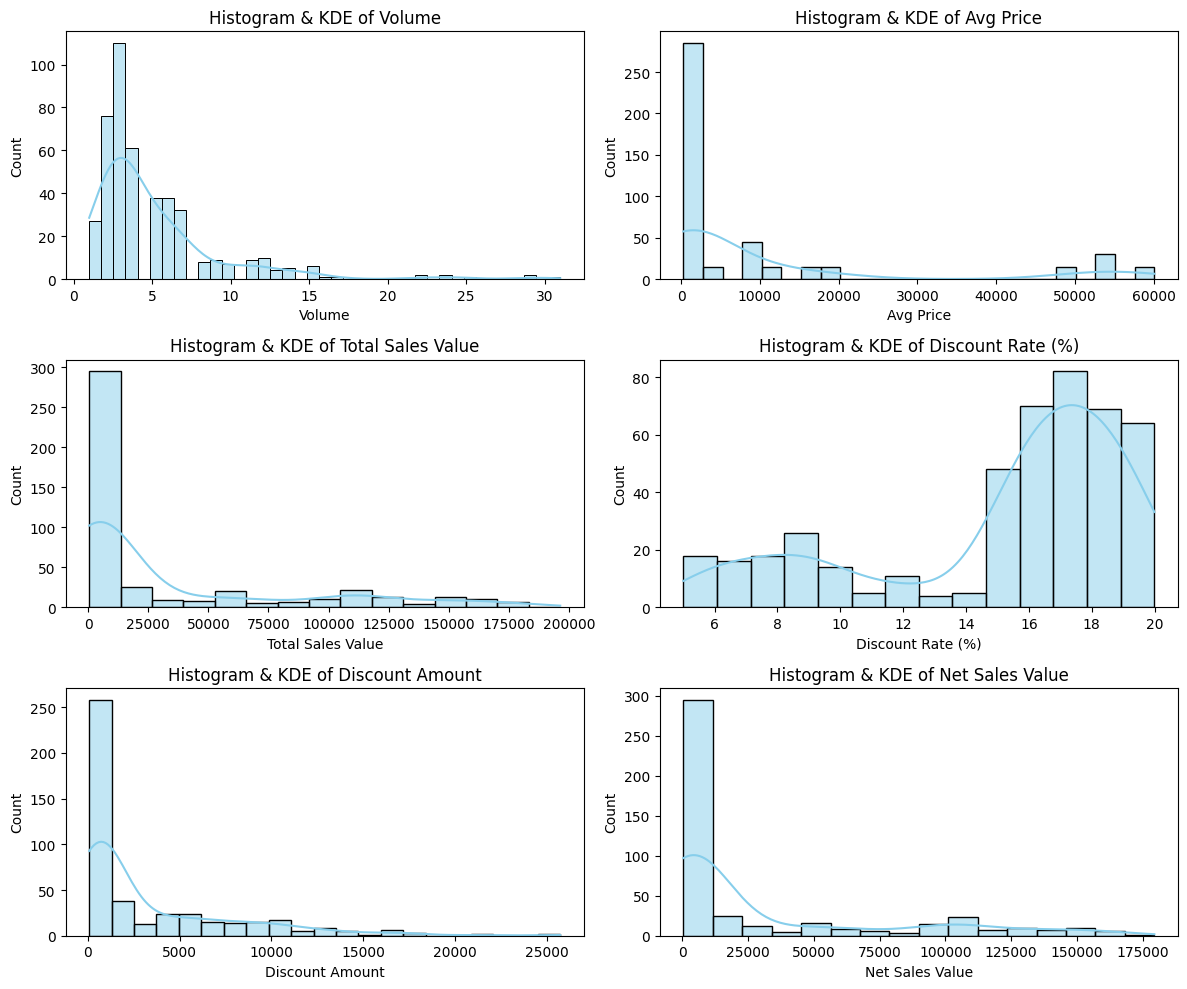

In [24]:
# Histograms[cite: 3]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Histogram & KDE of {col}")

plt.tight_layout()
plt.show()

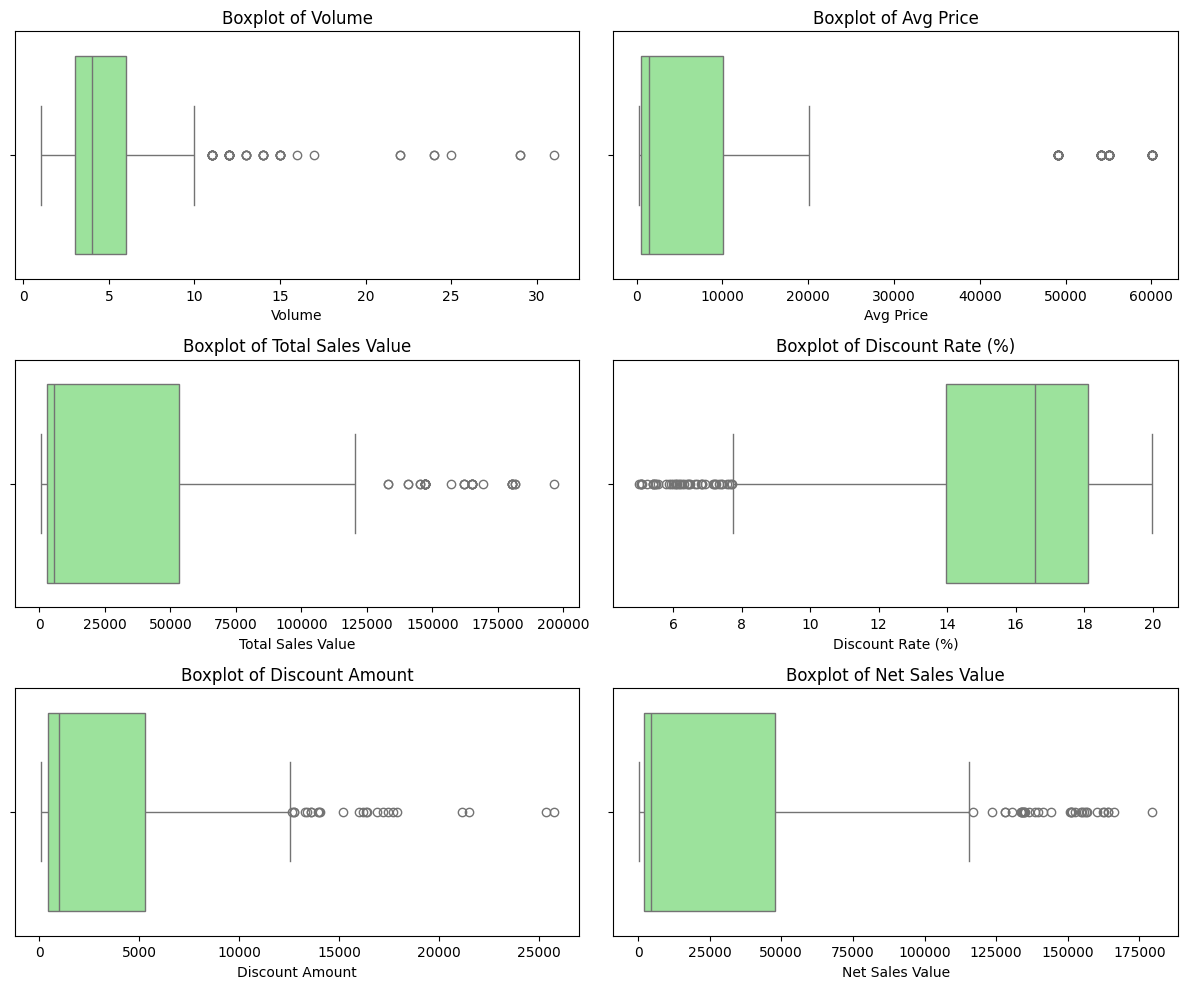

In [25]:
# Box Plots[cite: 3]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


Categorical Columns: ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


/tmp/ipykernel_889/1211918217.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Day", ax=axes[0, 0], palette="Set2")
/tmp/ipykernel_889/1211918217.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="BU", ax=axes[0, 1], palette="Set2")
/tmp/ipykernel_889/1211918217.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="City", ax=axes[1, 0], palette="Set2")
/tmp/ipykernel_889/1211918217.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assi

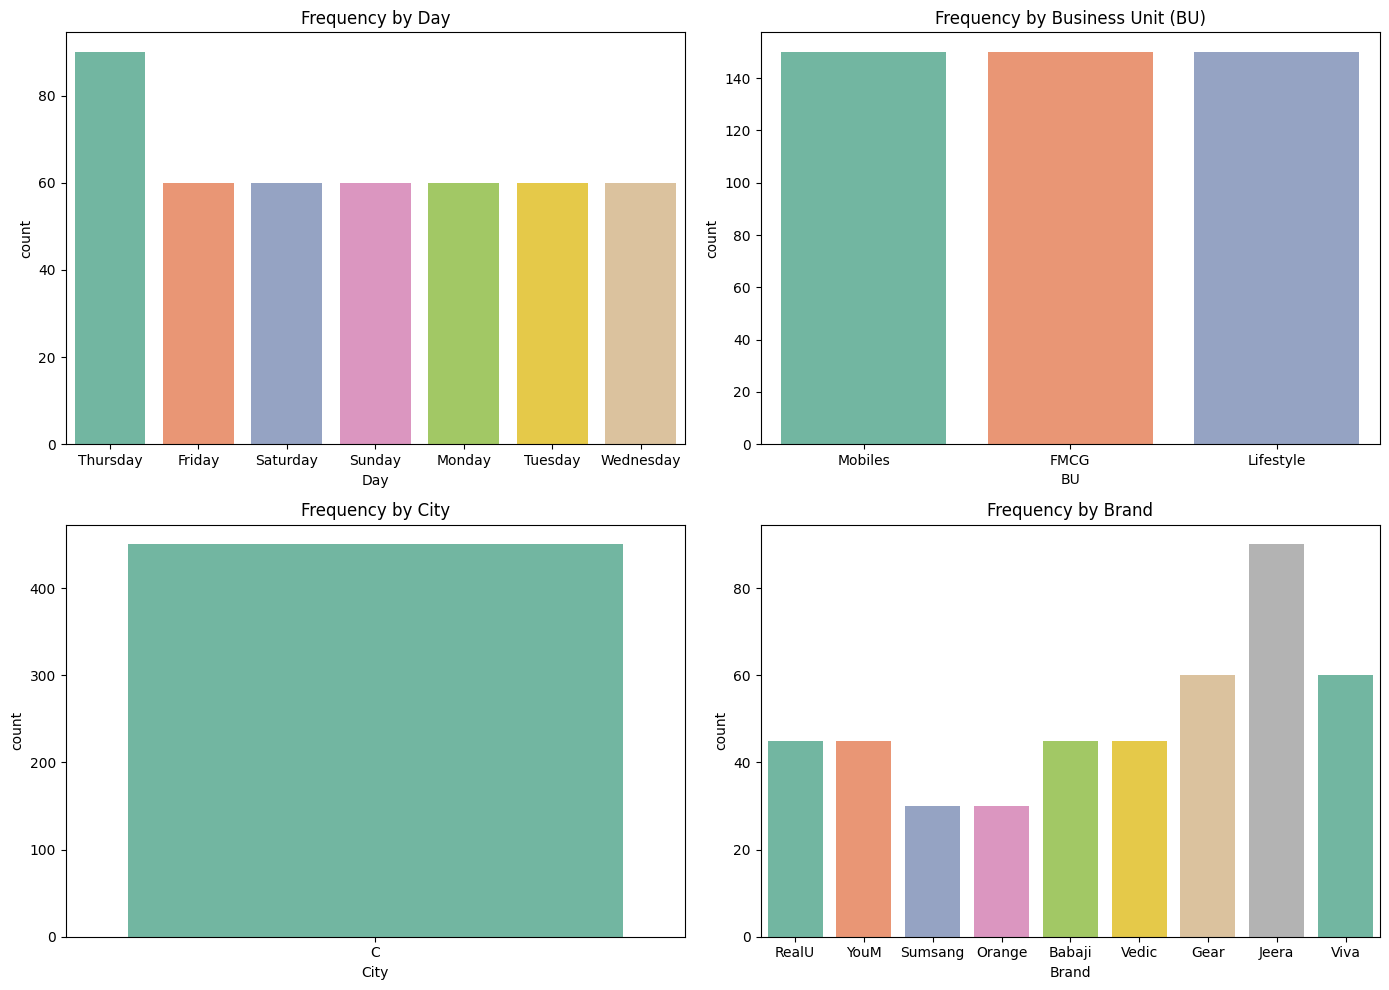

In [26]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("\nCategorical Columns:", cat_cols)

# Select key categorical columns for visualization[cite: 3]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Day", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Frequency by Day")

sns.countplot(data=df, x="BU", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Frequency by Business Unit (BU)")

sns.countplot(data=df, x="City", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Frequency by City")

sns.countplot(data=df, x="Brand", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Frequency by Brand")

plt.tight_layout()
plt.show()